# A Data-Centric Pipeline for Label Error Detection and Correction

**Question:** Can systematic detection and correction of mislabeled training examples improve
sentiment classification while the model architecture and training configuration stay fixed?

**Design:** IMDb train → inject known label noise of two kinds → Cleanlab (on frozen-BERT embeddings +
out-of-fold LogisticRegression) → clean (remove / hybrid) → fine-tune the *same* `bert-base-uncased` →
evaluate on the *same, untouched* test set.

**Two noise types:**
- **symmetric**: labels flipped uniformly at random (the textbook setting)
- **instance**: ambiguous reviews flipped far more often, like real annotator mistakes

## 1. Setup

In [1]:
import os

REPO_URL = "https://github.com/MUKAMAFrancois/data-centric-ai.git"
REPO_DIR = "data-centric-ai"

if not os.path.exists("src"):
    if not os.path.exists(REPO_DIR):
        !git clone -q {REPO_URL}
    %cd {REPO_DIR}
!git pull -q
!pip install -q -r requirements.txt

/content/data-centric-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.5 MB/s eta 0:00:00


In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch runtime to GPU!")

### Persist results across disconnects
Free Colab sessions die. With `USE_DRIVE = True`, results and the embedding cache are written to Google Drive,
so re-running the notebook resumes where it stopped.

In [2]:
from src.utils import load_config, set_seed

cfg = load_config("config.yaml")
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    base = "/content/drive/MyDrive/data-centric-ai"
    cfg["paths"].update({
        "cache_dir": f"{base}/cache",
        "results_file": f"{base}/experiments.csv",
        "issues_dir": f"{base}/label_issues",
    })

set_seed(cfg["seed"])
cfg["paths"]

Mounted at /content/drive


{'cache_dir': '/content/drive/MyDrive/data-centric-ai/cache',
 'results_file': '/content/drive/MyDrive/data-centric-ai/experiments.csv',
 'issues_dir': '/content/drive/MyDrive/data-centric-ai/label_issues',
 'figures_dir': 'results/figures'}

In [3]:
# Pilot switch: True for a quick check, False for the full experiment.
# Pilot runs are saved to the same results file, so the full run skips them.
PILOT = True

if PILOT:
    cfg["noise"]["types"] = ["instance"]
    cfg["noise"]["rates"] = [0.2]
    cfg["noise"]["seeds"] = [42]
    cfg["cleaning"]["strategies"] = ["remove"]

print("noise:", cfg["noise"], "| strategies:", cfg["cleaning"]["strategies"])

noise: {'types': ['instance'], 'rates': [0.2], 'seeds': [42]} | strategies: ['remove']


## 2. Load data

In [4]:
from src.data import load_imdb, profile_data, split_overlap

train_df, test_df = load_imdb(
    cfg["data"]["dataset_name"],
    cfg["data"]["train_subset"],
    cfg["data"]["test_subset"],
    cfg["seed"])
print(f"train: {len(train_df):,}   test: {len(test_df):,}")
train_df.head()

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

train: 10,000   test: 25,000


,id,text,label
0,0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,3,This film was probably inspired by Godard's Ma...,0
2,8,"Who are these ""They""- the actors? the filmmake...",0
3,10,It was great to see some of my favorite stars ...,0
4,12,Never cast models and Playboy bunnies in your ...,0


## 3. Data profiling (baseline data quality)

In [5]:
import pandas as pd

pd.DataFrame({"train": profile_data(train_df), "test": profile_data(test_df)})

,train,test
n_rows,10000,25000
class_counts,"{0: 5000, 1: 5000}","{0: 12500, 1: 12500}"
positive_rate,0.5,0.5
missing_text,0,0
empty_text,0,0
duplicate_rows,19,201
conflicting_duplicates,0,0
words_mean,229.9,226.3
words_median,172.0,170.0
words_p95,586.0,576.0


In [6]:
print("Exact train/test text overlap (leakage check):", split_overlap(train_df, test_df))

Exact train/test text overlap (leakage check): 48


## 4. Controlled label noise
We flip the same fraction of labels in each class and keep the original label in `true_label`.
This known ground truth is what lets us grade Cleanlab objectively.

- **Symmetric** noise picks the reviews to flip uniformly at random.
- **Instance-dependent** noise picks them with probability proportional to how *ambiguous* each review is.
  Ambiguity = 1 − P(true label) from an out-of-fold TF-IDF + LogisticRegression "annotator" model, which is
  deliberately different from the BERT-based detector so the noise generator and detector stay independent.

In [7]:
from src.data import ambiguity_scores, inject_noise

difficulty = ambiguity_scores(train_df["text"], train_df["label"], seed=cfg["seed"])

sym = inject_noise(train_df, 0.2, seed=42)
inst = inject_noise(train_df, 0.2, seed=42, noise_type="instance", difficulty=difficulty)
print(f"flipped: {inst.is_noisy.sum():,} of {len(inst):,}  |  class balance after: {inst.label.mean():.3f}")
print(f"mean ambiguity of flipped reviews  ->  random: {difficulty[sym.is_noisy.to_numpy()].mean():.3f}"
      f"   instance: {difficulty[inst.is_noisy.to_numpy()].mean():.3f}   (all reviews: {difficulty.mean():.3f})")

pd.set_option("display.max_colwidth", 300)
(inst[inst.is_noisy].assign(ambiguity=difficulty[inst.is_noisy.to_numpy()])
     .sort_values("ambiguity", ascending=False)[["id", "true_label", "label", "ambiguity", "text"]].head())

flipped: 2,000 of 10,000  |  class balance after: 0.500
mean ambiguity of flipped reviews  ->  random: 0.225   instance: 0.371   (all reviews: 0.225)


,id,true_label,label,ambiguity,text
8910,22257,1,0,0.992889,"This low-budget erotic thriller that has some good points, but a lot more bad one. The plot revolves around a female lawyer trying to clear her lover who is accused of murdering his wife. Being a soft-core film, that entails her going undercover at a strip club and having sex with possible suspe..."
4855,12148,0,1,0.953223,"I like Brad Pitt enormously. He is an actor with brains and wit, not to mention face, pectorals and all the rest. Since I saw him in ""Thelma and Louise"" a thought has been bothering me, who does he remind me of? ""Troy"" did it for me. He is the new Brigitte Bardot. The differences are obvious of ..."
7431,18531,1,0,0.952361,"Yes this a B- grade horror. But at least the producers, directors, and cast does not pretend this flick is manna from heaven. The plot is corny, a psychotic serial killer on his way to execution is splashed with genetic acid turning him into a snow man. The snowman a.k.a. Jack Frost then goes on..."
6189,15469,1,0,0.952030,"All good movies ""inspire"" some direct to video copycat flick. I was afraid that ""Gladiator"" wasn't really that good a film, because I hadn't seen any movie that had anything remotely resembling anything Roman on the new releases shelf for months. Then I spotted Full Moon's latest offering, Demon..."
1802,4459,0,1,0.951866,"I LOVE Don Knotts, let me just say that up-front! He is an enormous talent and the best at what he does, which is portray a nervous, lovably befuddled loser thrown into a position of authority. He is fabulous in this role as Roy Fleming, the Reluctant Astronaut, but the film is pretty dull, real..."


## 5. Frozen BERT embeddings (for the detector)
Frozen = BERT never sees our labels, so it can't memorise the noise. Computed once (~5-10 min on a T4) and cached.

In [8]:
from pathlib import Path
from src.model import embed_texts

det_cfg = cfg["detection"]
cache = Path(cfg["paths"]["cache_dir"]) / f"emb_{det_cfg['embed_model']}_{len(train_df)}_{det_cfg['embed_max_length']}.npy"
features = embed_texts(train_df["text"].tolist(), det_cfg["embed_model"], det_cfg["embed_max_length"],det_cfg["embed_batch_size"], str(cache))
features.shape

(10000, 768)

## 6. Label-error detection (Level 1: data quality)
Cheap: seconds per run. Out-of-fold LogisticRegression probabilities → Cleanlab → compare flags with the
labels we actually corrupted. Expect lower recall on instance noise: ambiguous reviews are hard to judge.

In [9]:
from src.pipeline import detect, plan_jobs

det_rows = []
for ntype, rate, seed in plan_jobs(cfg["noise"]):
    _, _, det = detect(train_df, features, rate, seed, det_cfg, ntype, difficulty)
    det_rows.append({"noise_type": ntype, "noise_rate": rate, "seed": seed, **det})

det_table = pd.DataFrame(det_rows)
det_table.groupby(["noise_type", "noise_rate"])[["n_true_errors", "n_flagged", "det_precision", "det_recall",
                                                 "det_f1", "review_reduction"]].mean().round(3)

,,n_true_errors,n_flagged,det_precision,det_recall,det_f1,review_reduction
noise_type,noise_rate,,,,,,
instance,0.2,2000.0,2078.0,0.603,0.626,0.614,0.792


### errors in the *original* IMDb labels
At 0% injected noise, anything Cleanlab flags is a candidate error in the real dataset. Read a few:
some will be genuinely mislabeled or ambiguous reviews.

In [10]:
from src.cleaning import find_issues, get_oof_probs

labels0 = train_df["label"].to_numpy()
issues0 = find_issues(labels0, get_oof_probs(features, labels0, det_cfg["cv_folds"], cfg["seed"]))
suspects = pd.concat([train_df, issues0], axis=1).query("is_label_issue").sort_values("label_quality")
print(f"{len(suspects):,} suspicious labels in the original training subset")
pd.set_option("display.max_colwidth", 300)
suspects[["id", "label", "suggested_label", "label_quality", "text"]].head(10)

736 suspicious labels in the original training subset


,id,label,suggested_label,label_quality,text
1270,3116,0,1,0.000010,"Great movie - especially the music - Etta James - ""At Last"". This speaks volumes when you have finally found that special someone."
662,1623,0,1,0.000011,"this film has it all; the deft camera work, reminiscent of martin scorcese, or oliver stone, the tight acting of 'heat', the explosive action of a jerry bruckheimer movie, the witty dialogue of a tarantino script and the epic feel of say, 'the godfather' the judge reinhold character displays a f..."
764,1890,0,1,0.000055,"Working with one of the best Shakespeare sources, this film manages to be creditable to it's source, whilst still appealing to a wider audience. Branagh steals the film from under Fishburne's nose, and there's a talented cast on good form."
8558,21403,1,0,0.000114,"This movie started slowly, then gained momentum towards the middle. However, the fact that the movie ran over two nights broke that momentum at its peak. The second part really got interesting, but then gave way to a simply pathetic ending. Playing football in the yard? Really, could it get any ..."
2054,5113,0,1,0.000120,"this one of the best celebrity's reality shows a ever saw. we can see the concerts we can see the life of Britney, i love the five episodes. i was always being surprised by Britney and the subjects of the show i think that some people don't watch the show at all we can how a great person she his..."
3731,9314,0,1,0.000168,"This video guide was the masterpiece of the year 1995. Beautifully done! Matthew Perry and Jennifer Aniston have major on-screen chemistry when they talk about what the Start button does. I'm waiting for Microsoft to release a Special Edition DVD complete with deleted scenes, Bill Gates commenta..."
1649,4089,0,1,0.000193,"I do agree with everything Calamine has said! And I don't always agree with people, but what Calamine has said is very true, it is time for the girls to move on to better roles. I would like to see them succeed very much as they were a very inspirational pair growing up and I would like to see t..."
5386,13459,1,0,0.000212,"This is a movie that has a lot of things that only Japanese people can understand. Even well translated, there are some things that are obviously private jokes or regional symbolism. My guess is that it tried to send a message of some sort, but that just got wasted on me. What I felt that is bas..."
8665,21648,1,0,0.000287,"Who ever came up with story is one sick person. I rented it for our slumber party sleepover and all six of us got freaked out cause we're all in an acting class together, and we know a couple of the actors from class. Besides everybody screaming the whole freaky night, I had freaky nightmares. I..."
9491,23705,1,0,0.000339,"Bad script, bad direction, over the top performances, overwrought dialogue. What more could you ask for? For laughs, it just doesn't get any better than this. Zadora's over-acting combined with the cliched scenarios she finds herself in make for an hilarious parody of the ""Hollywood"" machine. Al..."


## 7. Train the SAME BERT on clean / noisy / cleaned data (Level 2: model quality)
Every run uses identical hyperparameters from `config.yaml`. Each finished run is appended to the results
CSV

In [11]:
from src.model import fine_tune_and_predict
from src.pipeline import run_experiments

results = run_experiments(cfg, train_df, test_df, features, fine_tune_and_predict,results_file=cfg["paths"]["results_file"],issues_dir=cfg["paths"]["issues_dir"])
results.tail()

[noise] scoring review ambiguity for instance-dependent noise ...
[detect] instance noise=20% seed=42: flagged 2078 (true errors 2000, precision 0.603, recall 0.6265)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/7922 [00:00<?, ? examples/s]

Step,Training Loss
100,0.577747
200,0.311767
300,0.268441
400,0.287795
500,0.286542
600,0.205848
700,0.174476
800,0.145398
900,0.151236


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

   [train] cleaned_remove   n=  7922  residual_noise=0.094  acc=0.8840  f1=0.8858  (341.2s)


,noise_type,noise_rate,seed,dataset,strategy,n_train,n_wrong_labels,residual_noise,n_true_errors,n_flagged,...,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,train_seconds
0,symmetric,0.2,42,noisy,none,10000,2000,0.2000,2000,2931,...,0.9016,0.8893,0.9174,0.9031,0.9638,11072,1428,1032,11468,425.0
1,symmetric,0.2,42,cleaned_remove,remove,7069,446,0.0631,2000,2931,...,0.8998,0.9070,0.8910,0.8989,0.9630,11358,1142,1363,11137,339.2
2,none,0.0,42,clean,none,10000,0,0.0000,0,736,...,0.9158,0.9104,0.9224,0.9164,0.9726,11365,1135,970,11530,439.4
3,instance,0.2,42,noisy,none,10000,2000,0.2000,2000,2078,...,0.8877,0.8717,0.9093,0.8901,0.9579,10827,1673,1134,11366,408.1
4,instance,0.2,42,cleaned_remove,remove,7922,747,0.0943,2000,2078,...,0.8840,0.8726,0.8994,0.8858,0.9528,10858,1642,1258,11242,341.2


## 8. Results

In [12]:
from src.evaluate import recovery_table, summarize, with_noise_type

results = with_noise_type(pd.read_csv(cfg["paths"]["results_file"]))
summarize(results, metrics=("accuracy", "precision", "recall", "f1"))

,noise_type,noise_rate,dataset,accuracy,precision,recall,f1,n_seeds
0,instance,0.2,cleaned_remove,0.8840 ± 0.0000,0.8726 ± 0.0000,0.8994 ± 0.0000,0.8858 ± 0.0000,1
1,instance,0.2,noisy,0.8877 ± 0.0000,0.8717 ± 0.0000,0.9093 ± 0.0000,0.8901 ± 0.0000,1
2,none,0.0,clean,0.9158 ± 0.0000,0.9104 ± 0.0000,0.9224 ± 0.0000,0.9164 ± 0.0000,1
3,symmetric,0.2,cleaned_remove,0.8998 ± 0.0000,0.9070 ± 0.0000,0.8910 ± 0.0000,0.8989 ± 0.0000,1
4,symmetric,0.2,noisy,0.9016 ± 0.0000,0.8893 ± 0.0000,0.9174 ± 0.0000,0.9031 ± 0.0000,1


In [13]:
recovery_table(results, "f1")

,noise_type,noise_rate,strategy,clean_f1,noisy_f1,cleaned_f1,recovery_rate
0,instance,0.2,remove,0.9164,0.8901,0.8858,-0.1635
1,symmetric,0.2,remove,0.9164,0.9031,0.8989,-0.3158


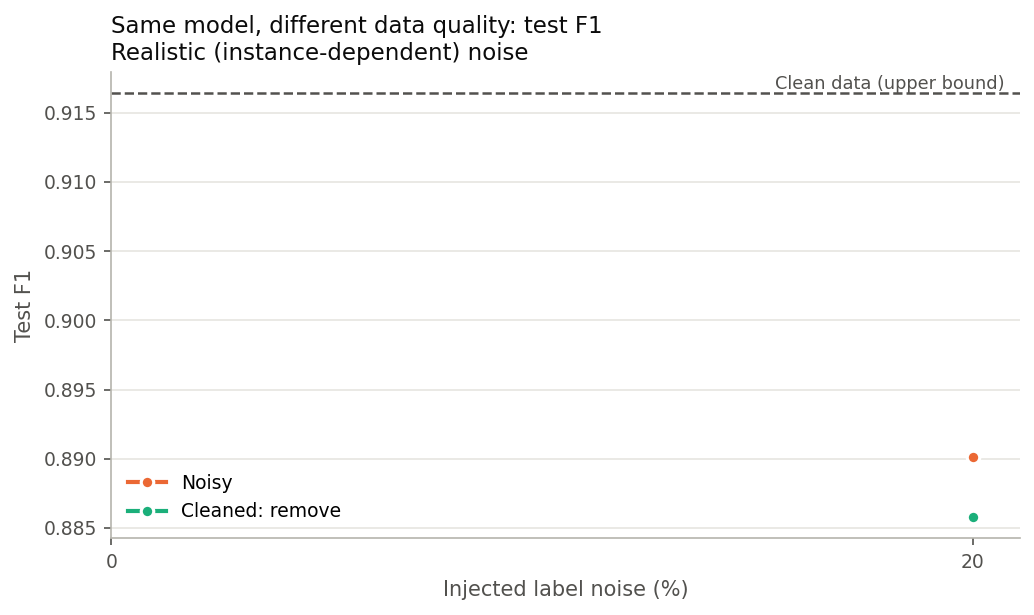

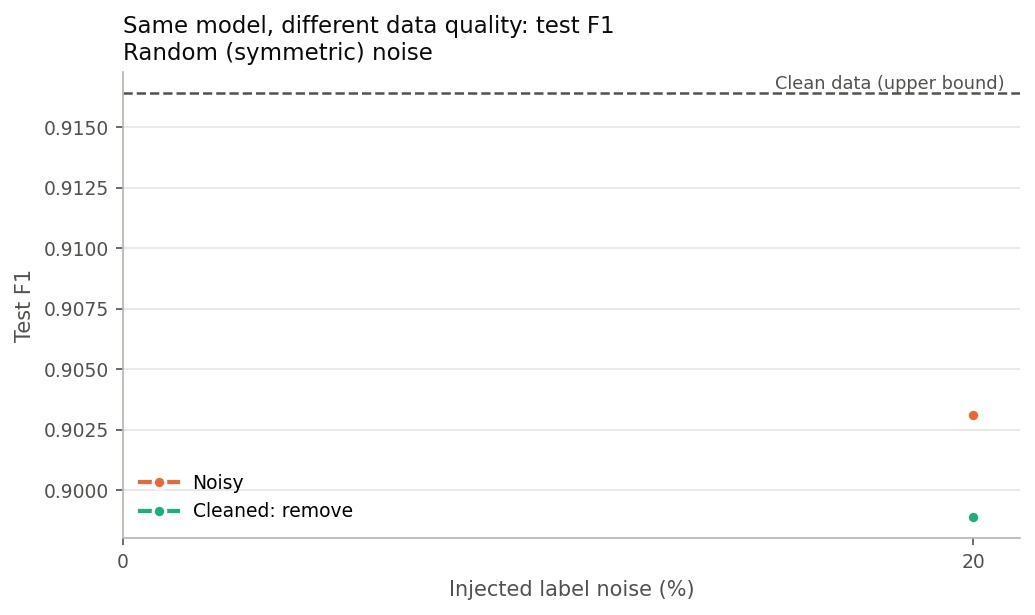

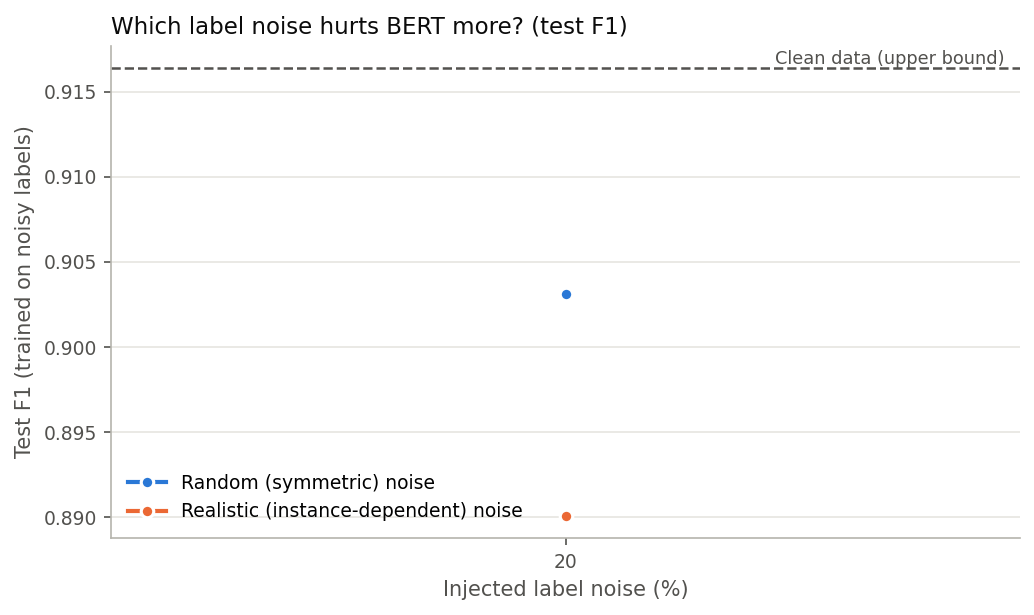

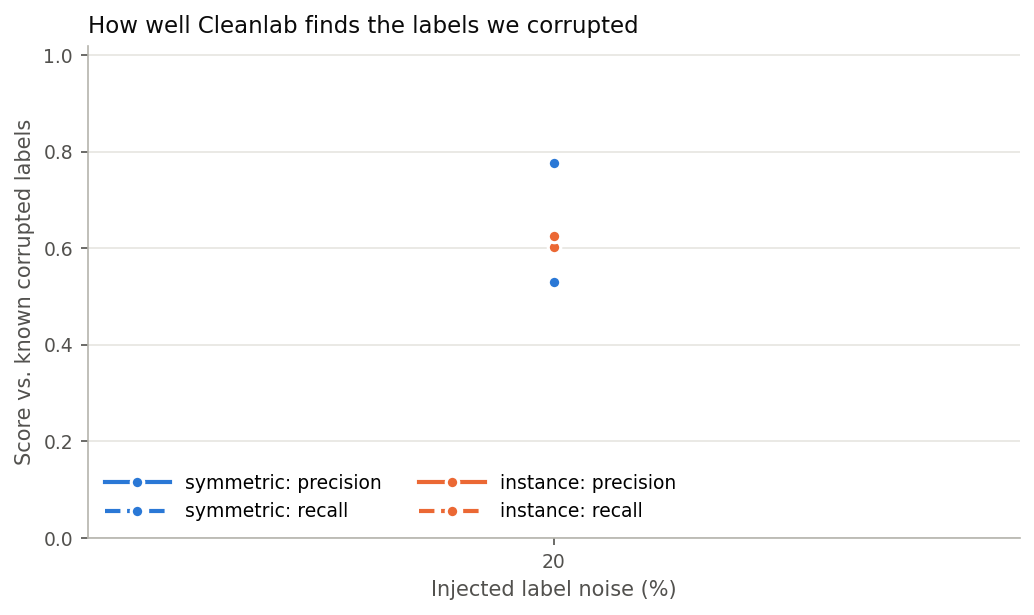

In [14]:
from src.evaluate import plot_detection, plot_metric_vs_noise, plot_noise_type_comparison

fig_dir = cfg["paths"]["figures_dir"]
for ntype in sorted(set(results["noise_type"]) - {"none"}):
    plot_metric_vs_noise(results, "f1", f"{fig_dir}/f1_vs_noise_{ntype}.png", noise_type=ntype)
plot_noise_type_comparison(results, "f1", f"{fig_dir}/noise_type_comparison.png")
plot_detection(results, f"{fig_dir}/detection_vs_noise.png");

skip cleaned_hybrid: not run yet
skip cleaned_relabel: not run yet


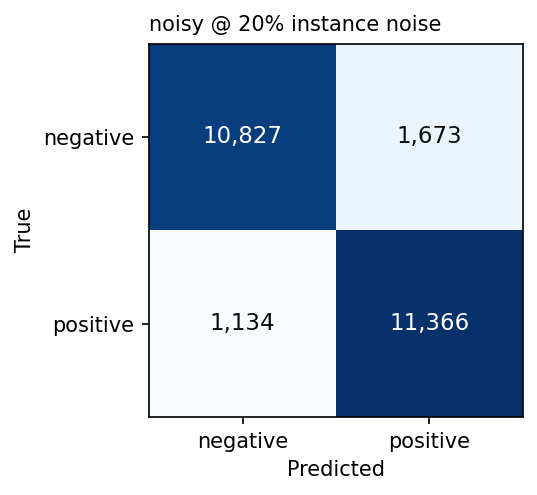

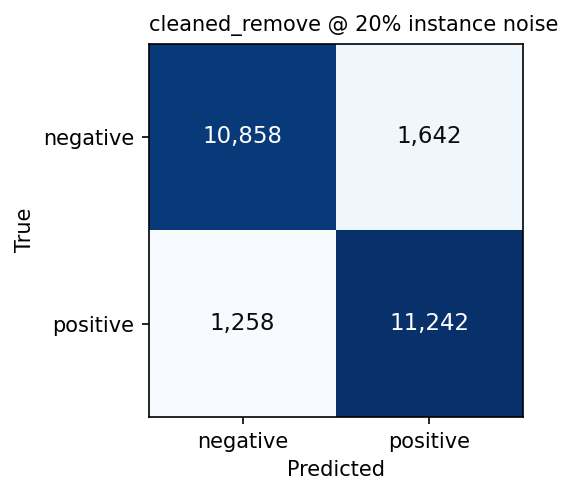

In [15]:
from src.evaluate import plot_confusion

NTYPE, RATE, SEED = "instance", 0.2, cfg["noise"]["seeds"][0]
for name in ["noisy", "cleaned_remove", "cleaned_hybrid", "cleaned_relabel"]:
    match = results.query("noise_type == @NTYPE and noise_rate == @RATE and seed == @SEED and dataset == @name")
    if match.empty:
        print(f"skip {name}: not run yet")
        continue
    plot_confusion(match.iloc[0], f"{name} @ {RATE:.0%} {NTYPE} noise",
                   f"{fig_dir}/cm_{NTYPE}_{name}_{int(RATE*100)}.png")

## 9. Error analysis
Which flags were *wrong* (flagged, but we never corrupted them)? These are often reviews that are
genuinely ambiguous or mislabeled in the original IMDb, which is an interesting finding in itself.

In [16]:
from pathlib import Path
from src.pipeline import issues_filename

NTYPE, RATE, seed = "instance", 0.2, cfg["noise"]["seeds"][0]
path = Path(cfg["paths"]["issues_dir"]) / issues_filename(NTYPE, RATE, seed)
if not path.exists():
    print(f"skip: {path.name} not created yet")
else:
    flagged = pd.read_csv(path)
    false_flags = flagged[~flagged["is_noisy"]]
    print(f"flagged: {len(flagged):,}   truly corrupted: {flagged.is_noisy.sum():,}   false flags: {len(false_flags):,}")
    display(false_flags[["id", "true_label", "label", "suggested_label", "label_quality", "text"]].head(10))

flagged: 2,078   truly corrupted: 1,253   false flags: 825


,id,true_label,label,suggested_label,label_quality,text
10,10534,0,0,1,0.006250,"Early, heavy, war-time propaganda short urging people to be careful with their spending practices, in effort to prevent any runaway inflation. Using scare, guilt and patriotic jingoistic rhetoric, which was normal for the time, the government was concern that the sudden war-time production and t..."
24,15956,1,1,0,0.010299,"This was a great movie but it had the worst ending I think I have ever seen!!! The actors were great and displayed wonderful talent. The entire story was twisted and unexpecting, which, is what made it entertaining. As good as the movie was, the entire film is judged by the ending, which was ter..."
35,20165,1,1,0,0.014762,"The young lady's name is Bonnie (Polay). She's attractive, is apparently living a pretty decent life, but all of a sudden is inexplicably snatched from her home and life by Evil Dude and the Various and Sundry Evil Henchmen. Now she has no idea what the hell is going on, only that a bunch of arm..."
45,4089,0,0,1,0.017548,"I do agree with everything Calamine has said! And I don't always agree with people, but what Calamine has said is very true, it is time for the girls to move on to better roles. I would like to see them succeed very much as they were a very inspirational pair growing up and I would like to see t..."
51,2457,0,0,1,0.019144,"* Some spoilers * This movie is sometimes subtitled ""Life Everlasting."" That's often taken as reference to the final scene, but more accurately describes how dead and buried this once-estimable series is after this sloppy and illogical send-off. There's a ""hey kids, let's put on a show air"" abou..."
53,5113,0,0,1,0.019519,"this one of the best celebrity's reality shows a ever saw. we can see the concerts we can see the life of Britney, i love the five episodes. i was always being surprised by Britney and the subjects of the show i think that some people don't watch the show at all we can how a great person she his..."
65,21024,1,1,0,0.022940,"A very funny east-meets-west film influenced by the closure of GM's Flint, Michigan plant in the eighties and the rise and integration of Japanese automakers in the US. Set in western Pennsylvania, it features great performances by Michael Keaton, Gedde Watanabe, and George Wendt. Music by blues..."
82,2333,0,0,1,0.027290,"A surprising misfire from the usually reliable Larry Cohen (God Told Me Too, Q, etc.), Full Moon High tries so hard to be funny and fails miserably, even with decent turns by Ed McMahon(!) and Kenneth Mars. Alan Arkin looks embarrassed throughout his performance and son Adam simply looks numb. T..."
88,18911,1,1,0,0.031564,hello. i just watched this movie earlier today for the 14th time in 3 days. i am a history teacher that has wayyyyy too much time on my hands. i need a life. i found the movie containing a striking resemblance to broke back mountain. i also found that i look a lot like jean Lafitte if he were wh...
92,16641,1,1,0,0.032545,"This movie is a true reflection of the Australian resourcefulness that has been required to make this country what it is over the last 200 years. Not pompous like the British, not Gung-Ho like the Americans. If either of those countries had attempted what this crew did, it would have failed dism..."


## 10. Download results
Bundles the results CSV, flagged-label files and figures into one zip. Unzip it into `results/` on your
laptop and commit from there (no GitHub token needed in Colab).

In [17]:
import shutil
from google.colab import files

out = "results_bundle"
shutil.copytree(cfg["paths"]["figures_dir"], f"{out}/figures", dirs_exist_ok=True)
shutil.copy(cfg["paths"]["results_file"], f"{out}/experiments.csv")
shutil.copytree(cfg["paths"]["issues_dir"], f"{out}/label_issues", dirs_exist_ok=True)
shutil.make_archive(out, "zip", out)
files.download(f"{out}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>